In [3]:
import numpy as np
import matplotlib.pyplot as plt
import load_mnist

In [4]:
# load data using functions coded in load_mnist.py
X_train = load_mnist.load_images(load_mnist.f_training_images)/255.0
y_train = load_mnist.load_labels(load_mnist.f_training_labels)

X_test = load_mnist.load_images(load_mnist.f_test_images)/255.0
y_test = load_mnist.load_labels(load_mnist.f_test_labels)

In [5]:
def train_ridge_classifier(X, y, lam):
    """ridge-regularized LS classifier for a match with the supplied digit
    the basic formula is w=(X.T@X)^(-1)X^Ty, but we create y as a membership matrix    
    """
    # create a matrix for y, where columns yj contain a 1 if yi=j, -1 if yi<>j
    y_mat = load_mnist.digit_2_matrix(y)
    
    # calculate weights using ridge regularizer
    w = np.linalg.inv(X.T@X + (lam * np.eye(X.shape[1])))@X.T@y_mat
    
    return w

# Test performance with $10^{-5} \leq \lambda \leq 10^{10}$

In [6]:
lam_arr = np.logspace(-5,10,20)
err_train = np.zeros(len(lam_arr))
err_test = np.zeros(len(lam_arr))

for i, lam in enumerate(lam_arr):
    
    # train the model using the training set
    w = train_ridge_classifier(X_train, y_train, lam)
    
    # demonstrate the model error with the training data
    y_hat = load_mnist.matrix_2_digit(X_train@w)
    err_train[i] = 1 - np.sum(np.equal(y_hat, y_train)) / len(y_train)
    
    # use the test set to measure error
    y_hat = load_mnist.matrix_2_digit(X_test@w)
    err_test[i] = 1 - np.sum(np.equal(y_hat, y_test)) / len(y_test)

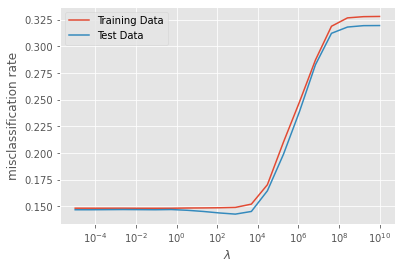

In [7]:
plt.plot(lam_arr, err_train, label='Training Data')
plt.plot(lam_arr, err_test, label='Test Data')

plt.xlabel(r'$\lambda$')
plt.ylabel('misclassification rate')

plt.semilogx()
plt.legend()

# Demonstrate L2-regularized least-squares classifier

In [8]:
# weight matrix m-rows x 10-cols, column represents weights for classifying that digit
w = train_ridge_classifier(X_train, y_train, 1e3)

# test using test dataset
y_hat = load_mnist.matrix_2_digit(X_test@w)
error_rate = 1-np.sum(np.equal(y_hat, y_test)) / len(y_test)

print('Error rate: {:0.2%}'.format(error_rate))

Error rate: 14.15%


# Explore bias of classifier

In [34]:
import pandas as pd

df = pd.DataFrame(data=np.hstack((y_test, np.equal(y_hat,y_test))), columns=['digit', 'correct'])
pt = df.pivot_table(index='digit', values=['correct', 'correct'], aggfunc=[len, np.sum])
pt = pt.stack().reset_index()
pt['error'] = 1-pt['sum']/pt['len']

In [35]:
pt

,digit,level_1,len,sum,error
0,0.0,correct,980.0,940.0,0.040816
1,1.0,correct,1135.0,1107.0,0.024670
2,2.0,correct,1032.0,828.0,0.197674
3,3.0,correct,1010.0,886.0,0.122772
4,4.0,correct,982.0,876.0,0.107943
5,5.0,correct,892.0,602.0,0.325112
6,6.0,correct,958.0,888.0,0.073069
7,7.0,correct,1028.0,887.0,0.137160
8,8.0,correct,974.0,748.0,0.232033
9,9.0,correct,1009.0,823.0,0.184341


Text(0, 0.5, 'misclassification rate')

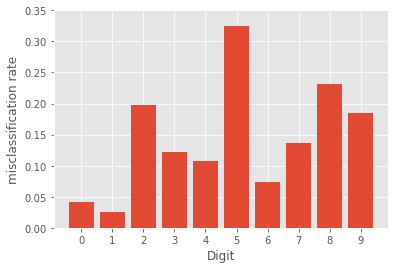

In [39]:
plt.bar(pt['digit'], pt['error'])
plt.xticks(range(10))
plt.xlabel('Digit')
plt.ylim(0,.35)
plt.ylabel('misclassification rate')